# Encoder-Only Transformer model

**Auteur**: `Jakob De Vreese`  
**Bachelorproef**: Overdraagbare unsupervised anomaliedetectie bij hybride HVAC-systemen  
**Academiejaar**: `2025-2026`  

## Doel

Bouwen en trainen van een **Encoder-Only Transformer Model** zoals gepresenteerd in *Transformer encoder based self-supervised learning for HVAC fault detection with unlabeled data* [(Abdollah et al., 2024)](http://dx.doi.org/10.1016/j.buildenv.2024.111568}). 

Dit model _wijkt af_ van de standaard **encoder-decoder architectuur** omdat anomaliedetectie in tijdreeksen **geen generatieve taak** is, wat de rekenkundige efficiëntie aanzienlijk verbetert. Het model maakt gebruik van _self-supervised learning_ via het `strategisch maskeren` van data.

### Verwachte brondata

Pre-processed multivariate dataset met HVAC-systeemdata (bijv. 10-minuten resolutie).

### Methodologische Kernconcepten
* **Time2Vec**: Voor het _inbedden_ van de temporele structuur (timestamps) in het model, aangezien een transformer van nature geen notie heeft van volgorde.
* **Markov Chain Masking**: Een autoregressieve pre-training taak waarbij _aaneengesloten segmenten_ van variabelen verborgen worden.
* **Peak Over Threshold (POT)**: Een statistische methode gebaseerd op de _Generalized Pareto Distribution_ (GPD) om dynamisch en automatisch de drempelwaarde voor anomalieën te bepalen.

### Stappenplan

- **Stap 1**: Data Preprocessing (Normalisatie & creatie van sliding windows)
- **Stap 2**: De Encoder-Only Architectuur (PyTorch implementatie inclusief Time2Vec)
- **Stap 3**: Self-Supervised Training (Markov chain block masking & berekening van MSE op uitsluitend de gemaskeerde delen)
- **Stap 4**: De Trainingsloop
- **Stap 5**: Hyperparameter Tuning & Model Opslaan
- **Stap 6**: Inferentie & Anomaliescores
- **Stap 7**: Validatie met Hybride Data

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, Model
import math
from scipy.stats import genpareto
import time
import os
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, classification_report, precision_recall_fscore_support,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
)

2026-04-21 17:54:36.676669: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## STAP 1 - Data Preprocessing

Voordat de data in het Keras-model wordt gevoed, wordt de volgende voorbereiding uitgevoerd:

1. **Data inlezen**
2. **Chronologische opsplitsing:** De tijdreeks wordt chronologisch opgesplitst (80% / 20%) om datalekkage te voorkomen.
3. **Standaardisatie:** De `StandardScaler` wordt uitsluitend gefit op de trainingsdata. Beide sets worden hiermee getransformeerd zodat het model geen statistieken van de testset leert.
4. **Sliding Windows:** Tijdreeksdata wordt opgedeeld in vaste *sliding windows*. De paper gebruikt een windowgrootte die exact overeenkomt met één dag. Bij een resolutie van 10 minuten is de `WINDOW_SIZE` 144.

### 1.1 Dataset inlezen

In [2]:
# Dataset inlezen
GEBOUW = 'dunant1'

url = f'../../data/processed/{GEBOUW}.csv'
data = pd.read_csv(url)
data.head()

,timestamp,f_1,f_2,f_3,f_4,f_6,f_7,f_8,f_9,f_10,...,f_50,f_51,f_52,f_53,f_54,f_55,is_weekdag,is_weekend,is_werkuur,uur
0,2026-03-09 00:00:00+00:00,0.0,0.00,1.0,39.038220,30.977285,1.0,18.945000,0.000000,0.0,...,0.0,4.223216,98.886563,0.639789,100.795459,0.0,1,0,0,0
1,2026-03-09 00:10:00+00:00,7.0,0.77,1.0,39.877285,31.832268,1.0,23.594538,44.640636,1.0,...,0.0,3.851797,99.589400,0.749325,86.946641,0.0,1,0,0,0
2,2026-03-09 00:20:00+00:00,9.0,0.78,1.0,41.921010,34.104786,1.0,46.930084,44.640636,1.0,...,0.0,3.903977,100.000000,0.559565,45.771835,0.0,1,0,0,0
3,2026-03-09 00:30:00+00:00,8.0,0.86,1.0,43.412975,35.585346,1.0,43.235270,44.640636,0.0,...,0.0,4.244891,99.196013,0.322963,91.228401,0.0,1,0,0,0
4,2026-03-09 00:40:00+00:00,7.0,0.78,1.0,43.734930,35.924030,1.0,48.845810,44.640636,0.0,...,0.0,4.448537,98.800579,0.300000,323.796930,0.0,1,0,0,0


In [3]:
print(data.shape)

(5040, 59)


### 1.2 Chronologische Train/Test split (80/20)

In [4]:
# Drop timestamp
if 'timestamp' in data.columns:
    data = data.drop(columns='timestamp')

# Splitsen in training en test (80% en 20%)
split_index = int(len(data) * 0.8)
train_data = data.iloc[:split_index]
test_data = data.iloc[split_index:]

print(f"Train data shape: {train_data.shape}")
print(f"Test data shape: {test_data.shape}")

Train data shape: (4032, 58)
Test data shape: (1008, 58)


### 1.3 Normalisatie van de data

In de paper spreekt men van standaardnormalisatie per **feature** voor de hele trainingsdataset. We gebruiken hiervoor de `StandardScaler()` van `scikit-learn`.

In [5]:
scaler = StandardScaler()
train_norm = scaler.fit_transform(train_data)
test_norm = scaler.transform(test_data) # Pas de normalisatie ook toe op de testdata

### 1.4 Sliding windows maken

In de paper spreekt men van een _window-size_ van $96$ tijdstappen, wat voor hun data overeenkomt met 1 dag.

In [6]:
WINDOW_SIZE = 144   # 1 dag data

In [7]:
# Hulpfunctie
def create_windows(data_array, window_size):
    windows = []
    for i in range(len(data_array) - window_size + 1):
        windows.append(data_array[i : i + window_size])
    return np.array(windows)

In [8]:
X_train_all = create_windows(train_norm, WINDOW_SIZE)
X_test = create_windows(test_norm, WINDOW_SIZE)

# Extra validatieset uit het einde van de train windows (chronologisch, geen shuffle)
val_ratio = 0.15
val_start = int(len(X_train_all) * (1 - val_ratio))
X_train = X_train_all[:val_start]
X_val = X_train_all[val_start:]

print(f"Vorm van de training data (X_train): {X_train.shape}")
print(f"Vorm van de validatie data (X_val): {X_val.shape}")
print(f"Vorm van de test data (X_test): {X_test.shape}")

Vorm van de training data (X_train): (3305, 144, 58)
Vorm van de validatie data (X_val): (584, 144, 58)
Vorm van de test data (X_test): (865, 144, 58)


Vorm van de tensor -> (aantal windows, tijdstappen per window, features)

## STAP 2 - De Encoder-Only Architectuur (Keras)

De paper kiest voor een architectuur die _uitsluitend_ uit een **encoder** bestaat. Omdat anomaliedetectie in deze context **geen generatieve taak** is (zoals taalvertaling of tekstgeneratie), is een decoder overbodig. Dit reduceert de complexiteit van het model en maakt de berekeningen aanzienlijk efficiënter.

We bouwen deze architectuur modulair op in vier stappen:

1. Hyperparameters definiëren
2. Time2Vec temporele encodering
3. De Transformer Encoder Laag
4. Het volledige model samenstellen

### 2.1 Hyperparameters

We nemen de specifieke dimensies en netwerkinstellingen over zoals beschreven in het onderzoek. De data wordt eerst geprojecteerd naar een interne dimensie (`d_model`), waarna het door multi-head attention blokken gaat.

* **`DIM_MODEL`**: De verborgen dimensie van het netwerk. We kiezen $140$ omdat dit deelbaar is door het aantal heads. Dit is een lineaire transformatie die de 54 features omzet in een abstracte vector van 140 getallen.
* **`NUM_HEADS`**: De paper gebruikt $7$ attention heads. In plaats van alle 140 dimensies in één keer te analyseren, deelt het model deze op in 7 parallelle _heads_. Het concept hier is dat elke _head_ zich zal _specialiseren_ in een ander type patroon (kortetermijn, dag/nacht-cyclus,...).
* **`NUM_LAYERS`**: Er worden $2$ opeenvolgende transformer-encoder lagen gebruikt. Dit representateert de _diepte_ van het netwerk. Het bepaalt hoeveel `Transformer-encoder` blokken er achter elkaar worden gestapeld. De paper gebruikt 2 lagen, omdat dit voor hun specifieke HVAC-data de beste balans biedt.

In [9]:
DIM_MODEL = 140
NUM_HEADS = 7    # Zoals in de paper
NUM_LAYERS = 2   # Zoals in de paper

### 2.2 Time2Vec (Temporele Encodering)

Een standaard Transformer bezit geen ingebouwd besef van de volgorde van data (tijd). Meestal wordt dit opgelost met statische sinus/cosinus positionele encoderingen. De paper kiest echter expliciet voor **Time2Vec** (Kazemi et al., 2019, geciteerd in de studie). 

Time2Vec is een model-agnostische vectorrepresentatie voor tijd die leerbare parameters bevat. Het vangt zowel lineaire trends als periodieke (seizoensgebonden) patronen op. De output van deze laag wordt opgeteld bij de geprojecteerde inputfeatures.

De formule bestaat uit twee componenten:
* Een lineaire component: $\tau \cdot w_0 + b_0$
* Een periodieke component (sinus): $\sin(\tau \cdot w + b)$

In [10]:
class Time2Vec(layers.Layer):
    def __init__(self, d_model, **kwargs):
        super(Time2Vec, self).__init__(**kwargs)
        self.d_model = d_model

    def build(self, input_shape):
        # Lineaire parameters (voor de niet-periodieke trend)
        self.w0 = self.add_weight(shape=(1, 1), initializer='random_normal', trainable=True, name='w0')
        self.b0 = self.add_weight(shape=(1, 1), initializer='random_normal', trainable=True, name='b0')
        
        # Periodieke parameters (sinus voor cyclische patronen)
        self.w = self.add_weight(shape=(1, self.d_model - 1), initializer='random_normal', trainable=True, name='w')
        self.b = self.add_weight(shape=(1, self.d_model - 1), initializer='random_normal', trainable=True, name='b')

    def call(self, tau):
        # tau is de input tijdstap matrix met shape: (batch_size, window_size, 1)
        v1 = tau * self.w0 + self.b0
        v2 = tf.math.sin(tau * self.w + self.b)
        
        # Concateneer de lineaire en periodieke representaties tot de d_model dimensie
        return tf.concat([v1, v2], axis=-1)

### 2.3 De Transformer Encoder Laag

Een enkel encoder-blok bestaat uit twee hoofdcomponenten, elk gevolgd door een *residual connection* (Add) en *Layer Normalization* (Norm):

1.  **Multi-Head Self-Attention**: Bepaalt hoe belangrijk elke tijdstap is ten opzichte van alle andere tijdstappen binnen hetzelfde window van 144 stappen.
2.  **Feed Forward Network (FFN)**: Een simpel neuraal netwerk dat de representaties verder transformeert. De dimensie wordt tijdelijk vergroot ($d\_model \times 4$) en dan weer teruggebracht.

In [11]:
class TransformerEncoderLayer(layers.Layer):
    def __init__(self, d_model, num_heads, **kwargs):
        super(TransformerEncoderLayer, self).__init__(**kwargs)
        self.mha = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)
        
        # Feed-forward netwerk met expansiefactor 4
        self.ffn = tf.keras.Sequential([
            layers.Dense(d_model * 4, activation='relu'),
            layers.Dense(d_model)
        ])
        
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)

    def call(self, x):
        # 1. Self-attention + Add & Norm
        attn_output = self.mha(x, x)
        out1 = self.layernorm1(x + attn_output)
        
        # 2. Feed Forward + Add & Norm
        ffn_output = self.ffn(out1)
        out2 = self.layernorm2(out1 + ffn_output)
        
        return out2

### 2.4 Het Volledige Transformer Model Samenstellen

Nu brengen we de onderdelen samen in de hoofdarchitectuur. De stroom van de data ($x$) verloopt als volgt:

1.  **Input Projectie**: De ruwe sensordata (bijv. 54 features) wordt lineair geprojecteerd naar de dimensie `d_model`. Dit gebeurt via een gewone `Dense` laag.
2.  **Positie Integratie**: De Time2Vec matrix wordt berekend op basis van de tijdstappen ($\tau$) en opgeteld bij de geprojecteerde input.
3.  **Encoder Blokken**: De resulterende matrix wordt iteratief door de `NUM_LAYERS` (2) encoder-lagen gestuurd.
4.  **Output Projectie**: De uiteindelijke output van de encoder wordt terug lineair geprojecteerd naar de originele feature-dimensie ($m = 54$) om de reconstructie te vormen.

In [12]:
class HVACAnomalyTransformer(Model):
    def __init__(self, num_features, d_model=DIM_MODEL, num_heads=NUM_HEADS, num_layers=NUM_LAYERS, **kwargs):
        super(HVACAnomalyTransformer, self).__init__(**kwargs)
        # 1. Projecteer naar interne d_model dimensie
        self.input_projection = layers.Dense(d_model)
        
        # 2. Temporele representatie
        self.time2vec = Time2Vec(d_model)
        
        # 3. Stack van encoder lagen
        self.encoder_layers = [TransformerEncoderLayer(d_model, num_heads) for _ in range(num_layers)]
        
        # 4. Reconstructie naar originele features
        self.output_projection = layers.Dense(num_features)

    def call(self, x):
        batch_size = tf.shape(x)[0]
        window_size = tf.shape(x)[1]
        
        # Creëer een oplopende index per tijdstap in het window (0 tot window_size - 1)
        # en geef dit de juiste dimensies voor Time2Vec: (batch_size, window_size, 1)
        tau = tf.range(window_size, dtype=tf.float32)
        tau = tf.reshape(tau, (1, window_size, 1))
        tau = tf.tile(tau, [batch_size, 1, 1])
        
        # Input projectie en Time2Vec optellen
        u = self.input_projection(x)
        w_pos = self.time2vec(tau)
        z = u + w_pos
        
        # Propagatie door de encoder lagen
        for encoder_layer in self.encoder_layers:
            z = encoder_layer(z)
            
        # Finale projectie terug naar het aantal originele sensoren/features
        reconstructed = self.output_projection(z)
        
        return reconstructed

In [13]:
# Initialisatie ter controle
NUM_FEATURES = X_train.shape[-1]
model = HVACAnomalyTransformer(num_features=NUM_FEATURES)
model.build(input_shape=(None, WINDOW_SIZE, NUM_FEATURES))
model.summary()

/home/jakob/Documents/vscode/hogent/.venv/lib/python3.12/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'hvac_anomaly_transformer', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "hvac_anomaly_transformer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time2_vec (Time2Vec)            │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_layer       │ ?                      │   0 (unbuilt) │
│ (TransformerEncoderLayer)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_layer_1     │ ?                      │   0 (unbuilt) │
│ (TransformerEncoderLayer)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## STAP 3 - Self-Supervised Training (Masking & Loss)

Omdat het verzamelen van gelabelde foutdata (waarbij een expert voor elke minuut heeft aangeduid of het HVAC-systeem correct werkt) in de praktijk extreem duur of onmogelijk is, gebruikt deze paper **Self-Supervised Learning (SSL)**. 

In plaats van het model te trainen op externe labels, creëren we een interne taak: we verbergen (maskeren) opzettelijk delen van de perfect normale trainingsdata en vragen het model om deze ontbrekende stukken in te vullen. Hierdoor wordt het model gedwongen om de onderliggende fysieke en thermodynamische wetten van het gebouw te leren.

Deze stap bestaat uit twee kernconcepten:

1. Het genereren van een Markov Chain blok-masker.
2. Het berekenen van de reconstructiefout uitsluitend op de gemaskeerde delen.

### 3.1 Markov Chain Block Masking

Een naïeve manier van maskeren is het willekeurig weglaten van individuele datapunten (zoals in standaard taalmodellen). Echter, HVAC-data is een tijdreeks met een hoge traagheid (bijv. de temperatuur in een kamer verandert heel langzaam). Als we slechts één tijdstap verbergen, kan het model de waarde simpelweg raden door het gemiddelde te nemen van de seconde ervoor en erna, zonder iets wezenlijks te leren.

De auteurs (Abdollah et al., 2024) lossen dit op door **Markov Chain Masking** toe te passen. Dit betekent dat we niet zomaar losse punten verbergen, maar aaneengesloten *segmenten* (blokken). Het model moet nu uren aan ontbrekende data voorspellen, wat dwingt tot een dieper begrip van de lange-termijn trends.

Parameters uit de paper:

* **Maskeerratio ($r$)**: Het percentage van de data dat we verbergen (ingesteld op $15\%$).
* **Gemiddelde bloklengte ($l_m$)**: De gemiddelde lengte van een aaneengesloten gemaskeerd segment (ingesteld op $3$ tijdstappen).

In [14]:
# Instelbare parameters
MASKEERRATIO = 0.15
GEMIDDELDE_BLOKLENGTE = 3

In [15]:
# Keras / TensorFlow implementatie van het Markov Chain masker
@tf.function
def create_block_mask_tf(batch_size, window_size, num_features, r=MASKEERRATIO, l_m=GEMIDDELDE_BLOKLENGTE):
    """
    Genereert een masker tensor van shape (batch_size, window_size, num_features).
    Waarde 1.0 = zichtbaar (originele data behouden)
    Waarde 0.0 = gemaskeerd (data wordt later vervangen door nullen)
    """
    # 1. Bereken hoeveel blokken van lengte l_m we moeten maskeren om aan ratio r te komen
    num_blocks = tf.cast(tf.cast(window_size, tf.float32) * r / float(l_m), tf.int32)
    
    # 2. Start met een leeg canvas waarbij alles zichtbaar is (1.0)
    mask = tf.ones((batch_size, window_size, num_features), dtype=tf.float32)

    # Subfunctie om het masker veilig per feature op te bouwen (AutoGraph compatibel)
    def build_mask():
        max_start = window_size - l_m
        
        def process_batch(single_mask):
            def process_feature(feature_mask):
                # Genereer willekeurige startposities voor de te verbergen blokken
                starts = tf.random.uniform(shape=[num_blocks], minval=0, maxval=max_start + 1, dtype=tf.int32)
                
                # TensorArray laat ons toe om veilig elementen aan te passen in een @tf.function
                ta = tf.TensorArray(tf.float32, size=window_size, dynamic_size=False, clear_after_read=False)
                ta = ta.unstack(feature_mask)
                
                # Overschrijf de geselecteerde blokken met 0.0
                for i in tf.range(num_blocks):
                    start_idx = starts[i]
                    for j in tf.range(l_m):
                        ta = ta.write(start_idx + j, 0.0)
                return ta.stack()
            
            # Pas dit toe op elke sensor (feature) afzonderlijk
            transposed_mask = tf.transpose(single_mask)
            updated_transposed = tf.map_fn(process_feature, transposed_mask)
            return tf.transpose(updated_transposed)

        return tf.map_fn(process_batch, mask)

    # 3. Voer de maskering uit, tenzij de ratio r zo klein is dat er geen blokken zijn
    final_mask = tf.cond(
        num_blocks <= 0,
        lambda: mask,          
        lambda: build_mask()   
    )
    
    return final_mask

### 3.2 Doelgerichte Verliesfunctie (Masked MSE)

Normaal berekent een autoencoder zijn verlies (Mean Squared Error) door de volledige input te vergelijken met de volledige output. 

De paper benadrukt echter dat de verliesfunctie **uitsluitend berekend mag worden over de gemaskeerde (verborgen) segmenten**. 

* **Waarom?** Als we het model ook zouden straffen voor fouten op de ongemaskeerde data (die het model gewoon als input krijgt), moedigen we het netwerk aan om een "identiteitsfunctie" te leren. Het zou simpelweg de input direct naar de output kopiëren zonder echt iets te snappen van het HVAC-systeem. Door alleen de loss op de verborgen delen te berekenen, meten we pure *voorspellende intelligentie*.

In [16]:
@tf.function
def masked_mse_loss_tf(original, reconstructed, mask):
    """
    Berekent de Mean Squared Error (MSE) exclusief over de gemaskeerde waarden.
    
    Parameters:
    - original: De originele, ongecensureerde data
    - reconstructed: De voorspelling van het model
    - mask: 1.0 = zichtbaar (mag niet meetellen), 0.0 = gemaskeerd (moet meetellen)
    """
    # 1. Inverteer het masker: 1 wordt 0, en 0 wordt 1.
    # Nu hebben alleen de posities die we moesten voorspellen de waarde 1.
    inverted_mask = 1.0 - mask
    
    # 2. Bereken de standaard kwadratische fout voor het volledige window
    squared_error = tf.square(reconstructed - original)
    
    # 3. Filter de fouten: vermenigvuldig met inverted_mask. 
    # Fouten op plekken die het model al kende, worden hiermee vermenigvuldigd met 0 en vallen weg.
    masked_squared_error = squared_error * inverted_mask
    
    # 4. Bereken het gemiddelde. We delen de totale som van de relevante fouten 
    # door het exacte aantal elementen dat we effectief verborgen hadden.
    # (1e-8 voorkomt een error wegens delen door nul)
    loss = tf.reduce_sum(masked_squared_error) / (tf.reduce_sum(inverted_mask) + 1e-8)
    
    return loss

## STAP 4 - De Trainingsloop

Omdat we in de vorige stap een dynamisch Markov Chain masker en een aangepaste verliesfunctie hebben gedefinieerd, is de standaard `model.fit()` methode van Keras niet langer toereikend. We bouwen in plaats daarvan een **Custom Training Loop**. 

Dit stelt ons in staat om voor elke individuele batch (een klein deel van de data) on-the-fly een nieuw, willekeurig masker te genereren en de optimalisatie van het netwerk handmatig te beheren met `tf.GradientTape`.

We bouwen dit op in drie logische delen:
1. Hyperparameters & Datavoorbereiding
2. De fundamentele trainingsstap (verwerking van één batch)
3. De iteratieve loop over de epochs

### 4.1 Hyperparameters & Datavoorbereiding

We definiëren de standaardvariabelen voor de training. De paper specificeert de Adam-optimizer, die bijzonder goed werkt met Transformer-architecturen.

Daarnaast verpakken we onze ruwe `numpy` arrays in een `tf.data.Dataset` object. Dit zorgt voor zeer efficiënte data-invoer naar de GPU/CPU. Het model verwerkt de data niet raam per raam, maar in batches (bijv. 32 windows tegelijk). We schudden (*shufflen*) de batches willekeurig door elkaar. Dit is toegestaan en voorkomt dat het model zich vastpint op de chronologische volgorde van de dagen; de temporele volgorde *binnen* elk window van 144 stappen is immers al behouden.

In [17]:
# Hyperparameters
NUM_EPOCHS = 10
BATCH_SIZE = 32
LEARNING_RATE = 1e-4

In [18]:
# We casten de data expliciet naar float32 voor compatibiliteit met Keras/TensorFlow
X_train_tf = tf.cast(X_train, tf.float32)
X_val_tf = tf.cast(X_val, tf.float32)

# TensorFlow Datasets aanmaken voor efficiënte batching en shuffling
train_dataset = tf.data.Dataset.from_tensor_slices(X_train_tf)
train_dataset = train_dataset.shuffle(buffer_size=1024).batch(BATCH_SIZE)

val_dataset = tf.data.Dataset.from_tensor_slices(X_val_tf).batch(BATCH_SIZE)

# Optimizer initialiseren
optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)

### 4.2 De Custom Training Step

Hier definiëren we wat er exact wiskundig gebeurt per batch. Deze logica bundelen we in een functie met de `@tf.function` decorator. Dit compileert de Python-code naar een statische TensorFlow-graaf, wat de berekeningen aanzienlijk versnelt.

De stap verloopt in deze specifieke volgorde:

1. **Maskering:** De `create_block_mask_tf` genereert een willekeurig blok-masker voor de huidige batch.
2. **Data corrumperen:** De inputdata wordt met het masker vermenigvuldigd. De te voorspellen segmenten veranderen in een reeks nullen.
3. **Forward Pass (`tf.GradientTape`):** De corrupte data wordt door de Transformer gestuurd. De `GradientTape` neemt alle wiskundige operaties "op".
4. **Loss Berekening:** De output wordt vergeleken met de *originele*, intacte data via onze `masked_mse_loss_tf`. De foutmarge wordt uitsluitend berekend op de segmenten die in stap 2 op nul waren gezet.
5. **Backpropagation:** We vragen de tape om de gradiënten (afgeleiden) te berekenen. Dit vertelt ons in welke richting elk gewicht in het netwerk moet worden aangepast om de fout te verkleinen.
6. **Update:** De optimizer past de gradiënten toe op de parameters van het model.

In [19]:
@tf.function
def train_step(batch_x, model, optimizer):
    # Dimensies dynamisch ophalen uit de huidige batch
    batch_size = tf.shape(batch_x)[0]
    window_size = tf.shape(batch_x)[1]
    num_features = tf.shape(batch_x)[2]
    
    # 1. Genereer het Markov Chain masker
    mask = create_block_mask_tf(batch_size, window_size, num_features, r=0.15, l_m=3)
    
    # 2. Pas het masker toe op de input (verborgen waarden worden 0.0)
    masked_x = batch_x * mask
    
    # 3. Open de tape voor backpropagation
    with tf.GradientTape() as tape:
        # Forward pass (zorg dat training=True staat i.v.m. layernorm en dropout)
        reconstructed = model(masked_x, training=True)
        
        # 4. Bereken de loss (uitsluitend over de gemaskeerde segmenten)
        loss = masked_mse_loss_tf(batch_x, reconstructed, mask)
        
    # 5. Bereken gradiënten
    gradients = tape.gradient(loss, model.trainable_variables)
    
    # 6. Pas gradiënten toe om de modelgewichten te updaten
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    
    return loss

### 4.3 De Iteratieve Epoch Loop

Een *epoch* is voltooid wanneer het model de volledige dataset (`train_dataset`) exact één keer heeft doorlopen in batches. We itereren over het gedefinieerde aantal epochs en houden de gemiddelde foutmarge (loss) per epoch bij. Als de training correct verloopt, zou deze gemiddelde loss na elke epoch stapsgewijs moeten dalen totdat het model convergeert.

In [20]:
print("Start van de training...")

for epoch in range(NUM_EPOCHS):
    start_time = time.time()
    
    # Keras variabele om het gemiddelde verlies van de epoch netjes bij te houden
    epoch_loss_avg = tf.keras.metrics.Mean()
    
    # Loop over alle batches in de dataset
    for batch_x in train_dataset:
        loss_value = train_step(batch_x, model, optimizer)
        epoch_loss_avg.update_state(loss_value)
        
    end_time = time.time()
    epoch_duration = end_time - start_time
    
    # Resultaat printen per epoch
    print(f"Epoch {epoch + 1:02d}/{NUM_EPOCHS:02d} | "
          f"Gemiddelde Loss: {epoch_loss_avg.result().numpy():.4f} | "
          f"Tijd: {epoch_duration:.1f}s")

print("Training voltooid.")

Start van de training...


W0000 00:00:1776786882.903744  272728 loop_optimizer.cc:934] Skipping loop optimization for Merge node with control input: StatefulPartitionedCall/cond/branch_executed/_36
W0000 00:00:1776787079.930521  272728 loop_optimizer.cc:934] Skipping loop optimization for Merge node with control input: StatefulPartitionedCall/cond/branch_executed/_36
2026-04-21 17:58:00.704813: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 01/10 | Gemiddelde Loss: 0.6651 | Tijd: 201.7s


2026-04-21 18:01:15.605035: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 02/10 | Gemiddelde Loss: 0.2801 | Tijd: 194.9s
Epoch 03/10 | Gemiddelde Loss: 0.2005 | Tijd: 194.4s


2026-04-21 18:07:42.409974: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 04/10 | Gemiddelde Loss: 0.1582 | Tijd: 192.4s
Epoch 05/10 | Gemiddelde Loss: 0.1392 | Tijd: 192.7s
Epoch 06/10 | Gemiddelde Loss: 0.1249 | Tijd: 192.4s
Epoch 07/10 | Gemiddelde Loss: 0.1166 | Tijd: 192.1s


2026-04-21 18:20:31.219699: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 08/10 | Gemiddelde Loss: 0.1065 | Tijd: 191.6s
Epoch 09/10 | Gemiddelde Loss: 0.0982 | Tijd: 192.0s
Epoch 10/10 | Gemiddelde Loss: 0.0952 | Tijd: 192.1s
Training voltooid.


## STAP 5 - Hyperparameter Tuning & Model Opslaan

Omdat we een custom architectuur gebruiken, is het belangrijk om de juiste hyperparameters te vinden. Een volledige *Grid Search* (waarbij elke mogelijke combinatie wordt getest) is voor Transformers vaak te rekenintensief voor een standaard laptop. Daarom gebruiken we een gecontroleerde iteratieve zoektocht over een beperkt aantal logische combinaties (bijv. het aantal dimensies en attention heads).

Na de zoektocht slaan we het best presterende model op. Omdat we werken met Keras *Model Subclassing* (custom lagen zoals `Time2Vec`), is de meest robuuste methode het opslaan van de **modelgewichten** (weights) in plaats van het hele modelobject. Dit voorkomt serialisatiefouten bij het inladen.

### 5.1 Grid samenstellen

In [21]:
# 1. Definieer de combinaties die we willen testen (Grid)
# We nemen ook learning_rate en masking mee omdat die sterk doorwegen in self-supervised pretraining.
hyperparameter_grid = [
    {'d_model': 96,  'num_heads': 4, 'num_layers': 2, 'learning_rate': 1e-4, 'mask_ratio': 0.15, 'block_len': 3},
    {'d_model': 128, 'num_heads': 8, 'num_layers': 2, 'learning_rate': 1e-4, 'mask_ratio': 0.15, 'block_len': 3},
    {'d_model': 140, 'num_heads': 7, 'num_layers': 2, 'learning_rate': 8e-5, 'mask_ratio': 0.20, 'block_len': 4},
    {'d_model': 168, 'num_heads': 8, 'num_layers': 3, 'learning_rate': 8e-5, 'mask_ratio': 0.20, 'block_len': 4},
]

### 5.2 Loop over de grid

In [22]:
best_loss = float('inf')
best_model = None
best_params = None

tuning_history = []
print("Start Hyperparameter Tuning...")

# Loop over de configuraties
for params in hyperparameter_grid:
    print(f"\n--- Testen van configuratie: {params} ---")

    # 1. Initialiseer en bouw het tijdelijke model
    temp_model = HVACAnomalyTransformer(
        num_features=NUM_FEATURES,
        d_model=params['d_model'],
        num_heads=params['num_heads'],
        num_layers=params['num_layers']
    )
    temp_model.build(input_shape=(None, WINDOW_SIZE, NUM_FEATURES))
    temp_optimizer = tf.keras.optimizers.Adam(learning_rate=params['learning_rate'])

    # 2. Lokale train/valid steps per configuratie (eigen TF grafiek)
    @tf.function
    def current_train_step(batch_x):
        batch_size = tf.shape(batch_x)[0]
        window_size = tf.shape(batch_x)[1]
        num_features = tf.shape(batch_x)[2]

        mask = create_block_mask_tf(
            batch_size,
            window_size,
            num_features,
            r=params['mask_ratio'],
            l_m=params['block_len']
        )
        masked_x = batch_x * mask

        with tf.GradientTape() as tape:
            reconstructed = temp_model(masked_x, training=True)
            loss = masked_mse_loss_tf(batch_x, reconstructed, mask)

        gradients = tape.gradient(loss, temp_model.trainable_variables)
        temp_optimizer.apply_gradients(zip(gradients, temp_model.trainable_variables))
        return loss

    @tf.function
    def current_val_step(batch_x):
        # Voor validatie houden we masking ook aan zodat de objective identiek is.
        batch_size = tf.shape(batch_x)[0]
        window_size = tf.shape(batch_x)[1]
        num_features = tf.shape(batch_x)[2]

        mask = create_block_mask_tf(
            batch_size,
            window_size,
            num_features,
            r=params['mask_ratio'],
            l_m=params['block_len']
        )
        masked_x = batch_x * mask

        reconstructed = temp_model(masked_x, training=False)
        return masked_mse_loss_tf(batch_x, reconstructed, mask)

    # 3. Train met eenvoudige early stopping op validatie
    max_epochs = 12
    patience = 3
    best_val_for_config = float('inf')
    best_epoch_for_config = -1
    wait = 0

    for epoch in range(max_epochs):
        train_loss_metric = tf.keras.metrics.Mean()
        for batch_x in train_dataset:
            train_loss_metric.update_state(current_train_step(batch_x))

        val_loss_metric = tf.keras.metrics.Mean()
        for batch_x in val_dataset:
            val_loss_metric.update_state(current_val_step(batch_x))

        epoch_train_loss = float(train_loss_metric.result().numpy())
        epoch_val_loss = float(val_loss_metric.result().numpy())

        print(
            f"Epoch {epoch + 1:02d}/{max_epochs:02d} | "
            f"train_loss={epoch_train_loss:.4f} | val_loss={epoch_val_loss:.4f}"
        )

        if epoch_val_loss < best_val_for_config:
            best_val_for_config = epoch_val_loss
            best_epoch_for_config = epoch + 1
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping geactiveerd op epoch {epoch + 1}.")
                break

    tuning_history.append({
        'params': params,
        'best_val_loss': best_val_for_config,
        'best_epoch': best_epoch_for_config
    })

    # 4. Controleer of dit het beste model tot nu toe is
    if best_val_for_config < best_loss:
        best_loss = best_val_for_config
        best_model = temp_model
        best_params = params

print(f"\nBeste configuratie gevonden: {best_params} met val_loss: {best_loss:.4f}")
print("\nTuning overzicht:")
for row in tuning_history:
    print(f"params={row['params']} | best_val_loss={row['best_val_loss']:.4f} | best_epoch={row['best_epoch']}")

Start Hyperparameter Tuning...

--- Testen van configuratie: {'d_model': 96, 'num_heads': 4, 'num_layers': 2, 'learning_rate': 0.0001, 'mask_ratio': 0.15, 'block_len': 3} ---


/home/jakob/Documents/vscode/hogent/.venv/lib/python3.12/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'hvac_anomaly_transformer_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
W0000 00:00:1776788818.753769  272728 loop_optimizer.cc:934] Skipping loop optimization for Merge node with control input: StatefulPartitionedCall/cond/branch_executed/_36
W0000 00:00:1776788973.078507  272728 loop_optimizer.cc:934] Skipping loop optimization for Merge node with control input: StatefulPartitionedCall/cond/branch_executed/_36
W0000 00:00:1776788973.999030  272728 loop_optimizer.cc:934] Skipping loop optimization for Merge node with control input: StatefulPartitionedCall/cond/branch_executed/_19
W0000 00:00:1776

Epoch 01/12 | train_loss=0.8821 | val_loss=0.3856
Epoch 02/12 | train_loss=0.4046 | val_loss=0.2861


2026-04-21 18:35:52.387644: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 03/12 | train_loss=0.3011 | val_loss=0.2489
Epoch 04/12 | train_loss=0.2419 | val_loss=0.2218
Epoch 05/12 | train_loss=0.2065 | val_loss=0.1997
Epoch 06/12 | train_loss=0.1837 | val_loss=0.1841
Epoch 07/12 | train_loss=0.1644 | val_loss=0.1730
Epoch 08/12 | train_loss=0.1549 | val_loss=0.1630
Epoch 09/12 | train_loss=0.1405 | val_loss=0.1540
Epoch 10/12 | train_loss=0.1324 | val_loss=0.1484


...

Epoch 01/12 | train_loss=0.8068 | val_loss=0.3297
Epoch 02/12 | train_loss=0.3488 | val_loss=0.2448


2026-04-21 19:59:37.244313: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 03/12 | train_loss=0.2563 | val_loss=0.2115
Epoch 04/12 | train_loss=0.2011 | val_loss=0.1850
Epoch 05/12 | train_loss=0.1738 | val_loss=0.1717
Epoch 06/12 | train_loss=0.1553 | val_loss=0.1566
Epoch 07/12 | train_loss=0.1393 | val_loss=0.1455
Epoch 08/12 | train_loss=0.1291 | val_loss=0.1403
Epoch 09/12 | train_loss=0.1214 | val_loss=0.1302
Epoch 10/12 | train_loss=0.1155 | val_loss=0.1262
Epoch 11/12 | train_loss=0.1128 | val_loss=0.1202
Epoch 12/12 | train_loss=0.1062 | val_loss=0.1162

--- Testen van configuratie: {'d_model': 168, 'num_heads': 8, 'num_layers': 3, 'learning_rate': 8e-05, 'mask_ratio': 0.2, 'block_len': 4} ---


/home/jakob/Documents/vscode/hogent/.venv/lib/python3.12/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'hvac_anomaly_transformer_4', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
W0000 00:00:1776796470.192027  272728 loop_optimizer.cc:934] Skipping loop optimization for Merge node with control input: StatefulPartitionedCall/cond/branch_executed/_36
W0000 00:00:1776796743.526907  272728 loop_optimizer.cc:934] Skipping loop optimization for Merge node with control input: StatefulPartitionedCall/cond/branch_executed/_36
W0000 00:00:1776796744.872976  272728 loop_optimizer.cc:934] Skipping loop optimization for Merge node with control input: StatefulPartitionedCall/cond/branch_executed/_19
W0000 00:00:1776

Epoch 01/12 | train_loss=0.6205 | val_loss=0.2779
Epoch 02/12 | train_loss=0.2661 | val_loss=0.2130
Epoch 03/12 | train_loss=0.1932 | val_loss=0.1851
Epoch 04/12 | train_loss=0.1566 | val_loss=0.1624
Epoch 05/12 | train_loss=0.1350 | val_loss=0.1492
Epoch 06/12 | train_loss=0.1213 | val_loss=0.1393
Epoch 07/12 | train_loss=0.1107 | val_loss=0.1272
Epoch 08/12 | train_loss=0.1031 | val_loss=0.1250
Epoch 09/12 | train_loss=0.0990 | val_loss=0.1206
Epoch 10/12 | train_loss=0.0952 | val_loss=0.1136
Epoch 11/12 | train_loss=0.0888 | val_loss=0.1152
Epoch 12/12 | train_loss=0.0836 | val_loss=0.1093

Beste configuratie gevonden: {'d_model': 128, 'num_heads': 8, 'num_layers': 2, 'learning_rate': 0.0001, 'mask_ratio': 0.15, 'block_len': 3} met val_loss: 0.1051

Tuning overzicht:
params={'d_model': 96, 'num_heads': 4, 'num_layers': 2, 'learning_rate': 0.0001, 'mask_ratio': 0.15, 'block_len': 3} | best_val_loss=0.1357 | best_epoch=12
params={'d_model': 128, 'num_heads': 8, 'num_layers': 2, 'learn

### 5.3 Beste model opslaan

In [23]:
# Model opslaan
gebouw_naam = "dunant1"
huidige_datum = datetime.now().strftime("%Y-%m-%d")
model_dir = "models"
os.makedirs(model_dir, exist_ok=True) 

save_path = f"{model_dir}/encoder-only-{gebouw_naam}-{huidige_datum}.weights.h5"
best_model.save_weights(save_path)

print(f"Beste model succesvol opgeslagen in: {save_path}")

Beste model succesvol opgeslagen in: models/encoder-only-dunant1-2026-04-21.weights.h5


## STAP 6 - Inferentie: Het model in de praktijk gebruiken

In deze stap simuleren we hoe het systeem in de praktijk wordt gebruikt. We gaan ervan uit dat het model op een server draait en nieuwe, onvoorziene gebouwdata binnenkrijgt.

We doen het volgende:

1. We initialiseren het model en laden de getrainde gewichten in.
2. We voeden de (normale) testdata aan het model en berekenen de reconstructiefout.
3. We gebruiken de **Peak Over Threshold (POT)** methode (op basis van de Generalized Pareto Distribution) om de "baseline" drempelwaarde voor dit specifieke gebouw te berekenen.

### 6.1 Initialisatie model en laden gewichten

In [24]:
# 1. Model opnieuw initialiseren en gewichten inladen (simulatie van praktijkgebruik)
# We gebruiken de best_params die we in Stap 5 hebben gevonden
loaded_model = HVACAnomalyTransformer(
    num_features=NUM_FEATURES,
    d_model=best_params['d_model'],
    num_heads=best_params['num_heads'],
    num_layers=best_params['num_layers']
)

# Forceer een build door dummy data door te geven, zodat de lagen geïnitialiseerd worden
loaded_model(tf.zeros((1, WINDOW_SIZE, NUM_FEATURES)))
loaded_model.load_weights(save_path)
print("Modelgewichten succesvol ingeladen!")

Modelgewichten succesvol ingeladen!


### 6.2 Voorspelling op ongeziene testdata

In [25]:
# Voorspellingen doen op de ongeziene testdata
X_test_tf = tf.cast(X_test, tf.float32)
reconstructions = loaded_model.predict(X_test_tf, batch_size=BATCH_SIZE)

28/28 ━━━━━━━━━━━━━━━━━━━━ 9s 313ms/step


In [26]:
# Anomaliescores berekenen (Som van de absolute fouten over alle sensoren per tijdstap)
scores_all_test = np.sum(np.abs(reconstructions - X_test), axis=-1)
flat_scores_all = scores_all_test.flatten()

print(flat_scores_all)

[18.25482753 18.98263973 21.06901632 ... 51.12718533 51.48345156
 50.90836362]


### 6.3 POT-methode

De functie `apply_pot_dynamic_thresholding` maakt gebruik van de **Extreme Waardetheorie (Extreme Value Theory - EVT)**. In plaats van een vaste, handmatige foutmarge te kiezen (zoals "alles met een foutscore boven de 5 is een defect"), berekent deze methode dynamisch wat wiskundig gezien een extreme en onwaarschijnlijke afwijking is, gebaseerd op de daadwerkelijke data van het gebouw.

Het algoritme doorloopt hiervoor vier gerichte stappen:

**1. Initiële drempel ($t$) instellen**
We nemen eerst alle anomaliescores (reconstructiefouten) en bepalen een baselinedrempel. In de code is dit standaard ingesteld op het 85e percentiel (`initial_percentile=85`). Dit betekent dat we de 85% laagste, normale foutmarges negeren. We focussen ons uitsluitend op de top 15% hoogste uitschieters (de "staart" van de verdeling).

**2. Excessen bepalen ($Y_i$)**
Voor alle waarden in die top 15% berekenen we de amplitude van de overschrijding. We trekken de drempelwaarde $t$ af van de score $X_i$. Wat overblijft noemen we de excessen: $Y_i = X_i - t$. 

**3. Generalized Pareto Distribution (GPD) fitten**
Volgens de Pickands-Balkema-de Haan stelling uit de extremewaardetheorie, volgen de excessen boven een voldoende hoge drempel altijd een specifieke kansverdeling: de **Generalized Pareto Distribution (GPD)**. 
Met de functie `genpareto.fit()` van de SciPy-bibliotheek zoekt het model de wiskundige curve die het beste bij deze excessen past. Dit resulteert in twee parameters:
* **Shape ($\gamma$ of `c`)**: Bepaalt de vorm (hoe snel de kans op een nog hogere foutwaarde afneemt).
* **Scale ($\sigma$ of `scale`)**: Bepaalt de statistische spreiding van de extreme waarden.

**4. De Dynamische Drempel ($Z_q$) berekenen**
Met de parameters van de GPD-curve bekend, kunnen we de definitieve alarmgrens bepalen op basis van een gekozen risiconiveau $q$ (bijv. `q=0.01`, wat staat voor 1% kans of tolerantie). 
Via de inverse cumulatieve verdelingsfunctie (de `ppf` of *Percent Point Function* in SciPy) zoeken we exact dat punt op de curve waarbij de kans dat een waarneming deze grens door toeval overschrijdt, gelijk is aan $q$. Deze waarde tellen we op bij onze initiële drempel $t$. 

Het resultaat is $Z_q$: een zeer strakke, wiskundig onderbouwde alarmgrens. Elke reconstructiefout die deze grens overschrijdt (`scores > z_q`), wordt aangeduid als anomalie.

In [27]:
# Peak Over Threshold (POT) Implementatie
def apply_pot_dynamic_thresholding(scores, q=1e-3, initial_percentile=85):
    """
    Past de POT-methode toe om anomalieën te detecteren.
    q: Risiconiveau (lage kans betekent een strengere drempel).
    """
    # Stap 1: Initiële drempel t instellen [cite: 444]
    t = np.percentile(scores, initial_percentile) # 85th percentile [cite: 446]
    
    # Stap 2: Excessen over de drempel bepalen [cite: 447]
    excesses = scores[scores > t] - t # Yi = Xi - t [cite: 448, 450]
    
    if len(excesses) == 0:
        print("Geen waarden overschrijden de initiële drempel. Pas de percentielwaarde aan.")
        return t, np.zeros_like(scores, dtype=bool)

    # Stap 3: Generalized Pareto Distribution (GPD) fitten met SciPy [cite: 451]
    # c is de shape parameter (gamma), loc is verplaatsing, scale is sigma [cite: 452, 484]
    c, loc, scale = genpareto.fit(excesses)
    
    # Stap 4: Dynamische drempel (kwantiel Zq) berekenen [cite: 492, 496]
    # We gebruiken de Percent Point Function (inverse van CDF) van SciPy
    z_q = t + genpareto.ppf(1 - q, c, loc=loc, scale=scale)
    
    print(f"Initiële drempel (t): {t:.4f}")
    print(f"GPD Parameters: Shape (gamma)={c:.4f}, Scale (sigma)={scale:.4f}")
    print(f"Berekende Dynamische Drempel (Z_q): {z_q:.4f}")
    
    # Bepaal welke scores een anomalie zijn [cite: 500]
    anomalies = scores > z_q
    return z_q, anomalies

In [28]:
baseline_threshold, _ = apply_pot_dynamic_thresholding(flat_scores_all, q=0.05, initial_percentile=80)

Initiële drempel (t): 18.7389
GPD Parameters: Shape (gamma)=-0.0397, Scale (sigma)=3.0269
Berekende Dynamische Drempel (Z_q): 27.2884


## STAP 7 - Evaluatie op Gelabelde Synthetische Data

In deze stap evalueren we het best getrainde model op de synthetische testset met ground-truth labels (`0=normaal`, `1=anomalie`).

We doen vier dingen:

1. Synthetische data en labels inladen
2. De data met dezelfde scaler transformeren en omzetten naar sliding windows
3. Anomaliescores berekenen en window-level labels maken
4. Evalueren met de POT-threshold uit Stap 6 en met een extra getunede threshold op een tuning-split

In [29]:
# 1) Synthetische dataset en labels inladen
synth_csv = f'../../data/processed/{GEBOUW}_test.csv'
labels_npy = f'../../data/processed/{GEBOUW}_test_labels.npy'

synth_df = pd.read_csv(synth_csv)
y_true_timestep = np.load(labels_npy).astype(int)

# Verwijder mogelijke index/timestamp kolommen en align met trainingsfeatures
if 'timestamp' in synth_df.columns:
    synth_df = synth_df.drop(columns=['timestamp'])
for col in list(synth_df.columns):
    if col.lower().startswith('unnamed'):
        synth_df = synth_df.drop(columns=[col])

synth_df = synth_df[train_data.columns]

# 2) Zelfde normalisatie als training + windows bouwen
synth_norm = scaler.transform(synth_df)
X_synth = create_windows(synth_norm, WINDOW_SIZE)

# Zet timestep labels om naar window labels: window is anomalie als eender welke timestep anomalie is
y_true_window = np.array([
    1 if np.max(y_true_timestep[i:i + WINDOW_SIZE]) > 0 else 0
    for i in range(len(y_true_timestep) - WINDOW_SIZE + 1)
], dtype=int)

print(f"Synthetische rows: {synth_df.shape[0]}")
print(f"Synthetische windows: {X_synth.shape}")
print(f"Window labels: {y_true_window.shape}, anomalies={y_true_window.sum()}")

Synthetische rows: 504
Synthetische windows: (361, 144, 58)
Window labels: (361,), anomalies=352


In [30]:
# 3) Inferentie en anomaly score op synthetische windows
X_synth_tf = tf.cast(X_synth, tf.float32)
recon_synth = loaded_model.predict(X_synth_tf, batch_size=BATCH_SIZE, verbose=0)

# Zelfde scoredefinitie als in Stap 6 (sum abs fout over features per tijdstap, dan mean over window)
scores_synth_timestep = np.sum(np.abs(recon_synth - X_synth), axis=-1)
scores_synth_window = np.mean(scores_synth_timestep, axis=1)

print(f"Score vector shape: {scores_synth_window.shape}")
print(f"Score min/mean/max: {scores_synth_window.min():.4f} / {scores_synth_window.mean():.4f} / {scores_synth_window.max():.4f}")

Score vector shape: (361,)
Score min/mean/max: 11.8976 / 14.7840 / 20.5180


In [31]:
# 4) Evaluatie met (a) POT-threshold uit clean data en (b) getunede threshold op synthetische tuning-split
# a) Clean POT-threshold
y_pred_pot = (scores_synth_window > baseline_threshold).astype(int)
cm_pot = confusion_matrix(y_true_window, y_pred_pot)
precision_pot, recall_pot, f1_pot, _ = precision_recall_fscore_support(
    y_true_window, y_pred_pot, average='binary', zero_division=0
)

# b) Threshold tuning op eerste 60% windows, evaluatie op laatste 40%
split_idx = int(len(scores_synth_window) * 0.6)
scores_tune, scores_eval = scores_synth_window[:split_idx], scores_synth_window[split_idx:]
y_tune, y_eval = y_true_window[:split_idx], y_true_window[split_idx:]

candidates = np.unique(np.quantile(scores_tune, np.linspace(0.01, 0.99, 300)))
best_f1 = -1.0
best_threshold = baseline_threshold

for thr in candidates:
    y_hat = (scores_tune > thr).astype(int)
    _, _, f1_tmp, _ = precision_recall_fscore_support(y_tune, y_hat, average='binary', zero_division=0)
    if f1_tmp > best_f1:
        best_f1 = f1_tmp
        best_threshold = float(thr)

y_pred_tuned_eval = (scores_eval > best_threshold).astype(int)
cm_tuned = confusion_matrix(y_eval, y_pred_tuned_eval)
precision_tuned, recall_tuned, f1_tuned, _ = precision_recall_fscore_support(
    y_eval, y_pred_tuned_eval, average='binary', zero_division=0
)

roc_auc_full = roc_auc_score(y_true_window, scores_synth_window)
pr_auc_full = average_precision_score(y_true_window, scores_synth_window)

print("=== Evaluatie op synthetische gelabelde windows ===")
print(f"POT threshold (clean): {baseline_threshold:.4f}")
print(f"Tuned threshold (synth tune split): {best_threshold:.4f}")
print("")
print("-- Volledige synth set met POT-threshold --")
print(cm_pot)
print(f"Precision={precision_pot:.4f} | Recall={recall_pot:.4f} | F1={f1_pot:.4f}")
print("")
print("-- Holdout synth eval split met tuned threshold --")
print(cm_tuned)
print(f"Precision={precision_tuned:.4f} | Recall={recall_tuned:.4f} | F1={f1_tuned:.4f}")
print("")
print(f"Score quality (threshold-onafhankelijk): ROC-AUC={roc_auc_full:.4f}, PR-AUC={pr_auc_full:.4f}")
print("")
print("Classification report (POT-threshold op volledige synth set):")
print(classification_report(y_true_window, y_pred_pot, digits=4, zero_division=0))

=== Evaluatie op synthetische gelabelde windows ===
POT threshold (clean): 27.2884
Tuned threshold (synth tune split): 13.5585

-- Volledige synth set met POT-threshold --
[[  9   0]
 [352   0]]
Precision=0.0000 | Recall=0.0000 | F1=0.0000

-- Holdout synth eval split met tuned threshold --
[[ 0  9]
 [97 39]]
Precision=0.8125 | Recall=0.2868 | F1=0.4239

Score quality (threshold-onafhankelijk): ROC-AUC=0.5170, PR-AUC=0.9837

Classification report (POT-threshold op volledige synth set):
              precision    recall  f1-score   support

           0     0.0249    1.0000    0.0486         9
           1     0.0000    0.0000    0.0000       352

    accuracy                         0.0249       361
   macro avg     0.0125    0.5000    0.0243       361
weighted avg     0.0006    0.0249    0.0012       361



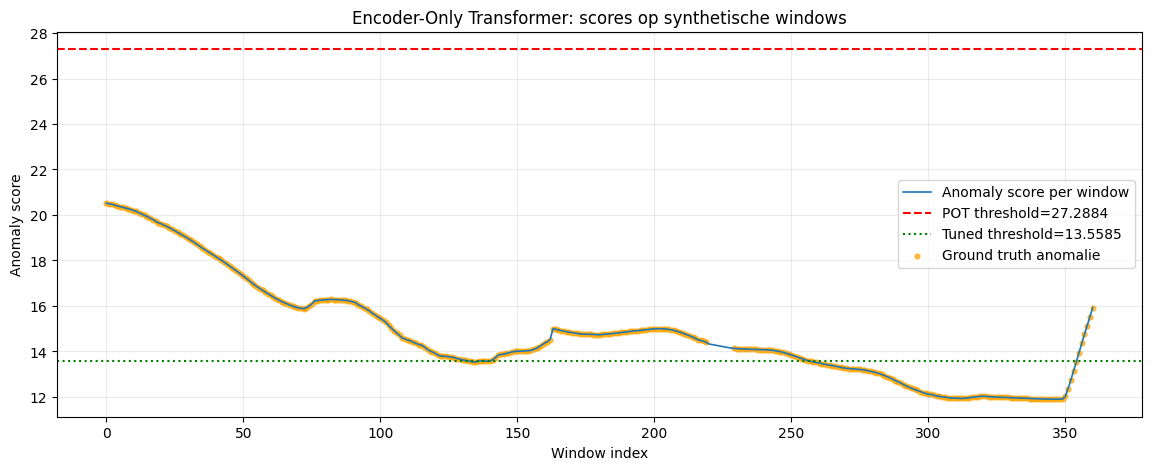

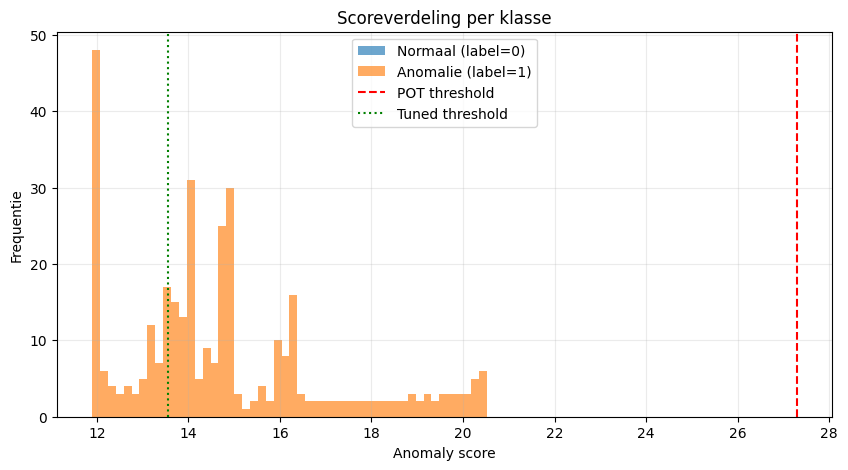

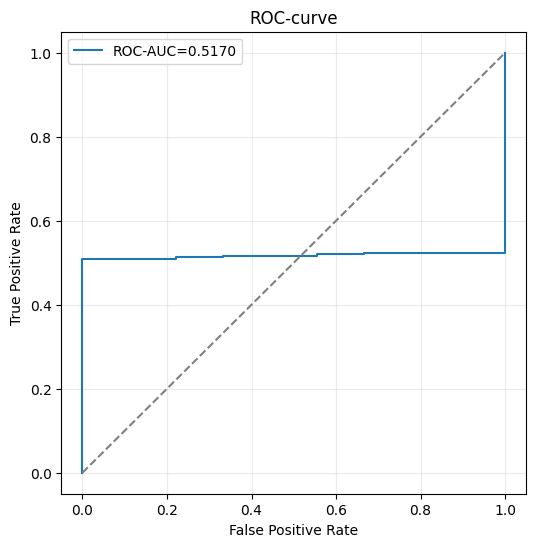

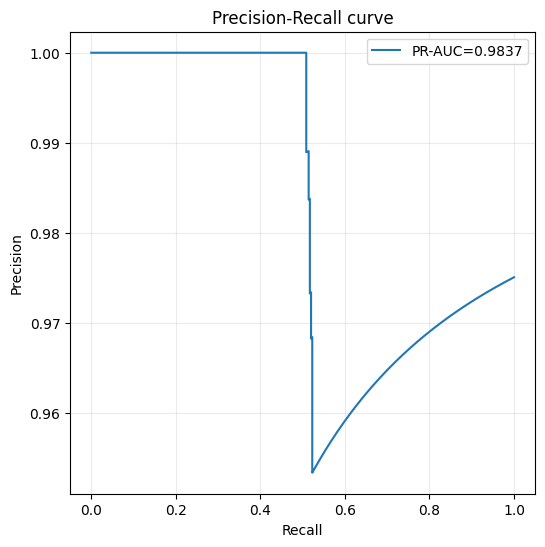

In [32]:
# 5) Visualisaties
# Plot 1: scores met thresholds en ground-truth
plt.figure(figsize=(14, 5))
plt.plot(scores_synth_window, label='Anomaly score per window', linewidth=1.2)
plt.axhline(y=baseline_threshold, color='red', linestyle='--', label=f'POT threshold={baseline_threshold:.4f}')
plt.axhline(y=best_threshold, color='green', linestyle=':', label=f'Tuned threshold={best_threshold:.4f}')

anom_idx = np.where(y_true_window == 1)[0]
plt.scatter(anom_idx, scores_synth_window[anom_idx], s=12, c='orange', alpha=0.7, label='Ground truth anomalie')

plt.title('Encoder-Only Transformer: scores op synthetische windows')
plt.xlabel('Window index')
plt.ylabel('Anomaly score')
plt.grid(alpha=0.25)
plt.legend()
plt.show()

# Plot 2: scoreverdeling per klasse
plt.figure(figsize=(10, 5))
plt.hist(scores_synth_window[y_true_window == 0], bins=50, alpha=0.65, label='Normaal (label=0)')
plt.hist(scores_synth_window[y_true_window == 1], bins=50, alpha=0.65, label='Anomalie (label=1)')
plt.axvline(x=baseline_threshold, color='red', linestyle='--', label='POT threshold')
plt.axvline(x=best_threshold, color='green', linestyle=':', label='Tuned threshold')
plt.title('Scoreverdeling per klasse')
plt.xlabel('Anomaly score')
plt.ylabel('Frequentie')
plt.grid(alpha=0.25)
plt.legend()
plt.show()

# Plot 3: ROC en PR
fpr, tpr, _ = roc_curve(y_true_window, scores_synth_window)
prec_curve, rec_curve, _ = precision_recall_curve(y_true_window, scores_synth_window)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'ROC-AUC={roc_auc_full:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('ROC-curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(alpha=0.25)
plt.legend()
plt.show()

plt.figure(figsize=(6, 6))
plt.plot(rec_curve, prec_curve, label=f'PR-AUC={pr_auc_full:.4f}')
plt.title('Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(alpha=0.25)
plt.legend()
plt.show()